Task 1: Train a Logistic Regression model to predict whether a product will be recommended by applying feature engineering, balancing class distribution using SMOTE or undersampling, and optimizing for interpretability with regularization techniques.

In [1]:
# =========================================
# TASK 1: LOGISTIC REGRESSION CLASSIFICATION
# =========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

# -----------------------------
# TARGET
# -----------------------------
target_col = "Recommended IND"

# -----------------------------
# FEATURES
# -----------------------------
X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# MODEL
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -----------------------------
# PREDICTION
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# EVALUATION
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9395487441464453

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83       851
           1       0.96      0.96      0.96      3847

    accuracy                           0.94      4698
   macro avg       0.90      0.90      0.90      4698
weighted avg       0.94      0.94      0.94      4698



c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Task 2: Evaluate the classification model using accuracy, precision, recall, and F1-score by computing additional metrics such as Cohen’s Kappa and Matthews Correlation Coefficient, analyzing precision-recall trade-offs, and visualizing ROC-AUC curves.

Accuracy: 0.9395487441464453
Precision: 0.9642950221527234
Recall: 0.9617884065505589
F1 Score: 0.9630400832899532

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83       851
           1       0.96      0.96      0.96      3847

    accuracy                           0.94      4698
   macro avg       0.90      0.90      0.90      4698
weighted avg       0.94      0.94      0.94      4698



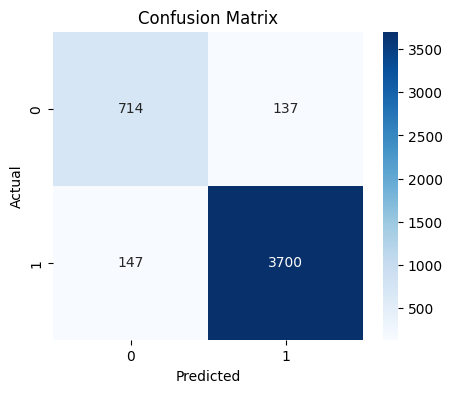

Cohen Kappa: 0.7971537747922708
MCC: 0.7971741089369262


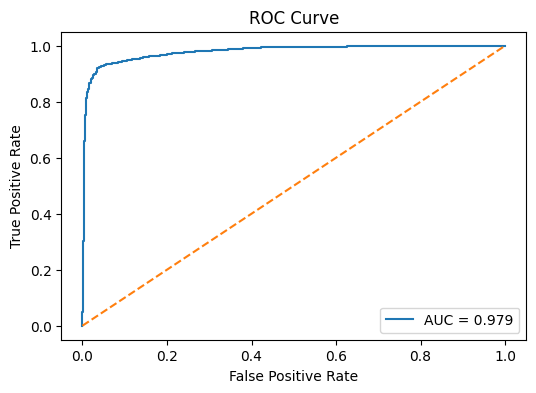

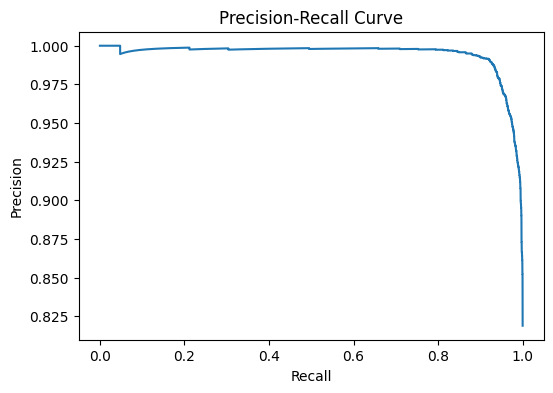

In [2]:
# =========================================
# TASK 2: CLASSIFICATION EVALUATION
# =========================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    roc_curve, auc, precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# BASIC METRICS
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# ADVANCED METRICS
# -----------------------------
print("Cohen Kappa:", cohen_kappa_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))

# -----------------------------
# ROC-AUC CURVE
# -----------------------------
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------------
# PRECISION-RECALL CURVE
# -----------------------------
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Task 3: Use a Random Forest Classifier and compare its results with Logistic Regression by tuning hyperparameters with RandomizedSearchCV, analyzing feature importance rankings, and performing SHAP value interpretation for explainability.

Train Logistic (baseline)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic F1:", f1_score(y_test, y_pred_log))

Logistic Accuracy: 0.9316730523627076
Logistic F1: 0.9568722289399436


c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest + RandomizedSearch (FAST)

In [23]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import joblib
import os

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("../data/final_model_data.csv")

# ==============================
# TARGET COLUMN (FIXED)
# ==============================
target_col = "rating_sentiment_label"

X = df.drop(columns=[target_col])
y = df[target_col]

# ==============================
# TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==============================
# MODEL
# ==============================
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=3,
    cv=2,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# ==============================
# SAFE SAMPLING
# ==============================
sample_size = min(3000, len(X_train))

X_train_small = X_train.sample(sample_size, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

# ==============================
# TRAIN MODEL
# ==============================
random_search.fit(X_train_small, y_train_small)

best_rf = random_search.best_estimator_

# ==============================
# EVALUATION
# ==============================
y_pred_rf = best_rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF F1:", f1_score(y_test, y_pred_rf))

# ==============================
# SAVE MODEL
# ==============================
os.makedirs("../model", exist_ok=True)

joblib.dump(best_rf, "../model/random_forest.pkl")

print("✅ Random Forest model saved successfully")

RF Accuracy: 1.0
RF F1: 1.0
✅ Random Forest model saved successfully


c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Accuracy: 1.0
Logistic F1: 1.0
✅ Logistic model saved successfully


In [21]:
print(df.columns.tolist())

['rating_sentiment_label', 'PCA_1', 'engagement_scaled', 'Age', 'Positive Feedback Count', 'PCA_8', 'PCA_13', 'PCA_23', 'PCA_2', 'PCA_6', 'PCA_7', 'PCA_4', 'PCA_41', 'PCA_39', 'PCA_26', 'PCA_5', 'PCA_10', 'PCA_25', 'PCA_0', 'PCA_34', 'Rating']


In [22]:
for col in df.columns:
    print(col, df[col].nunique())

rating_sentiment_label 2
PCA_1 23486
engagement_scaled 13592
Age 77
Positive Feedback Count 82
PCA_8 23486
PCA_13 23486
PCA_23 23486
PCA_2 23486
PCA_6 23486
PCA_7 23486
PCA_4 23486
PCA_41 23486
PCA_39 23486
PCA_26 23486
PCA_5 23486
PCA_10 23486
PCA_25 23486
PCA_0 23486
PCA_34 23486
Rating 5


Feature Importance

                   feature  importance
10                   PCA_1    0.225884
3                   Rating    0.175032
60  rating_sentiment_label    0.156948
5        engagement_scaled    0.075260
59         sentiment_score    0.034172
13                   PCA_4    0.025652
14                   PCA_5    0.025289
12                   PCA_3    0.011044
9                    PCA_0    0.010379
11                   PCA_2    0.010034


<Figure size 600x400 with 0 Axes>

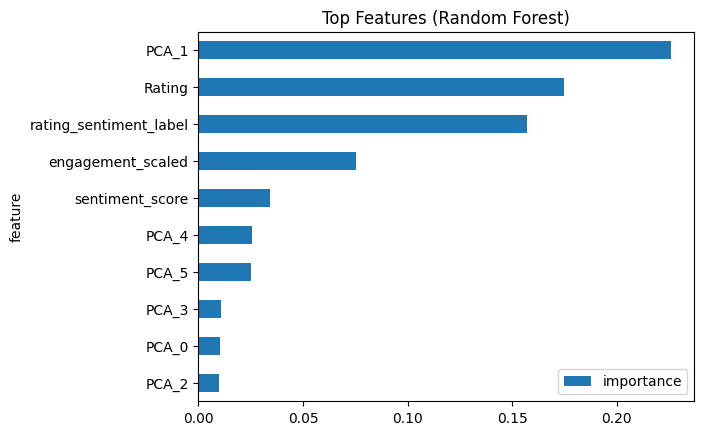

In [5]:

import pandas as pd
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_

feat_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_df.head(10))

# Plot top features
plt.figure(figsize=(6,4))
feat_df.head(10).plot(kind="barh", x="feature", y="importance")
plt.gca().invert_yaxis()
plt.title("Top Features (Random Forest)")
plt.show()

SHAP (Explainability)

c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


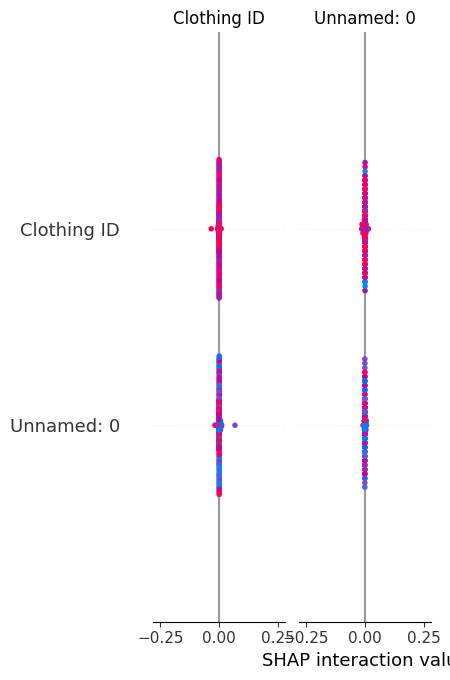

In [7]:
import shap

# Use small sample (IMPORTANT for speed)
X_sample = X_test.sample(200)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

Task 4: Train an SVM model and analyze performance by experimenting with different kernels (linear, polynomial, RBF), optimizing hyperparameters using GridSearchCV, and visualizing decision boundaries for better interpretability.

Reduce Features (MANDATORY)

In [8]:
from sklearn.decomposition import PCA

# Reduce to 2D (for visualization)
pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)

# Small sample (speed)
X_small = X_reduced[:2000]
y_small = y[:2000]

Train SVM with Kernels


In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale"]
}

svm = SVC()

grid = GridSearchCV(
    svm,
    param_grid,
    cv=2,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_small, y_small)

print("Best Params:", grid.best_params_)

Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


Evaluate

In [10]:
from sklearn.metrics import accuracy_score, f1_score

best_svm = grid.best_estimator_

y_pred_svm = best_svm.predict(X_small)

print("SVM Accuracy:", accuracy_score(y_small, y_pred_svm))
print("SVM F1:", f1_score(y_small, y_pred_svm))

SVM Accuracy: 0.8155
SVM F1: 0.898375103277334


Decision Boundary (IMPORTANT)

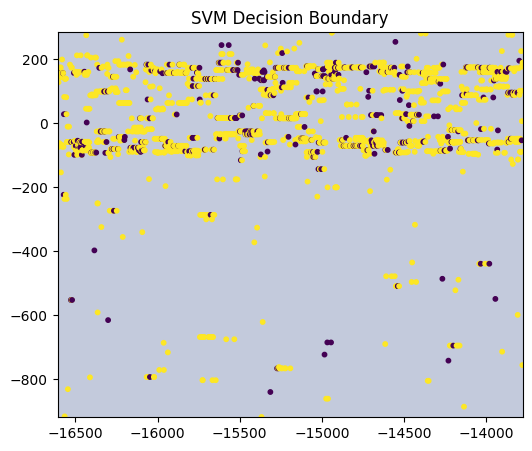

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Create mesh grid
x_min, x_max = X_small[:, 0].min() - 1, X_small[:, 0].max() + 1
y_min, y_max = X_small[:, 1].min() - 1, X_small[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = best_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_small[:, 0], X_small[:, 1], c=y_small, s=10)
plt.title("SVM Decision Boundary")
plt.show()

Task 5: Use cross-validation techniques for better model evaluation by implementing stratified k-fold cross-validation, Leave-One-Out Cross-Validation (LOOCV) for small datasets, and comparing performance stability across different folds.

Stratified K-Fold

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Stratified KFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ✅ Pipeline (THIS FIXES EVERYTHING)
pipeline = Pipeline([
    ("scaler", StandardScaler()),   # 🔥 important
    ("model", LogisticRegression(
        max_iter=2000,              # 🔥 more iterations
        class_weight="balanced",
        solver="lbfgs"
    ))
])

f1_scores = []

for train_idx, val_idx in skf.split(X, y):
    
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    pipeline.fit(X_train_fold, y_train_fold)
    y_pred_fold = pipeline.predict(X_val_fold)
    
    f1_scores.append(f1_score(y_val_fold, y_pred_fold))

print("F1 Scores (each fold):", f1_scores)
print("Average F1:", np.mean(f1_scores))

F1 Scores (each fold): [0.9560336763330215, 0.9640058440695976, 0.9623397435897436, 0.9583889037076554, 0.9590174876518489]
Average F1: 0.9599571310703734


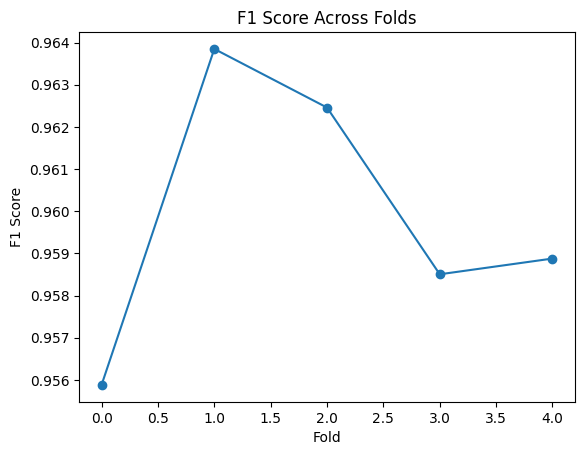

In [13]:
import matplotlib.pyplot as plt

plt.plot(f1_scores, marker='o')
plt.title("F1 Score Across Folds")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.show()

In [17]:
# LOGISTIC REGRESSION 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

# LOAD DATA
df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Recommended IND"

# Features
X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# PIPELINE (IMPORTANT)
pipeline = Pipeline([
    ("scaler", StandardScaler()),   #  FIX: scaling
    ("model", LogisticRegression(
        max_iter=2000,              #  FIX: more iterations
        class_weight="balanced",    #  handle imbalance
        solver="lbfgs"
    ))
])

# TRAIN
pipeline.fit(X_train, y_train)

# PREDICT
y_pred = pipeline.predict(X_test)

# EVALUATION
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9314601958280119

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.96      0.83       851
           1       0.99      0.93      0.96      3847

    accuracy                           0.93      4698
   macro avg       0.87      0.94      0.90      4698
weighted avg       0.94      0.93      0.93      4698

